# Cell 1 — Libraries

In [1]:
# Task 6: Wine Quality Prediction
# Intern: Suraj Kumar | OIB/J2/IP2626

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


# Cell 2 — Data Loading

In [2]:
# Step 2: Data Loading
df = pd.read_csv('WineQT.csv')

print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nFirst 5 rows:")
print(df.head())
print("\nQuality Distribution:")
print(df['quality'].value_counts())

Shape: (1143, 13)

Columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'Id']

First 5 rows:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3  

# Cell 3 — Data Preprocessing & Visualization

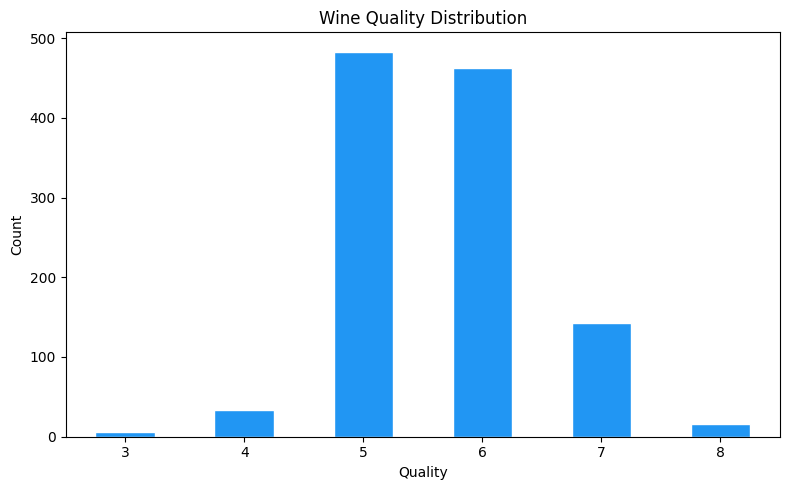

Basic Statistics:
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count        1143.00           1143.00      1143.00         1143.00   
mean            8.31              0.53         0.27            2.53   
std             1.75              0.18         0.20            1.36   
min             4.60              0.12         0.00            0.90   
25%             7.10              0.39         0.09            1.90   
50%             7.90              0.52         0.25            2.20   
75%             9.10              0.64         0.42            2.60   
max            15.90              1.58         1.00           15.50   

       chlorides  free sulfur dioxide  total sulfur dioxide  density       pH  \
count    1143.00              1143.00               1143.00  1143.00  1143.00   
mean        0.09                15.62                 45.91     1.00     3.31   
std         0.05                10.25                 32.78     0.00     0.16   
min         0.01  

In [3]:
# Step 3: Preprocessing & Visualization

# Drop Id column
df = df.drop('Id', axis=1)

# Graph 1 - Quality Distribution
plt.figure(figsize=(8,5))
df['quality'].value_counts().sort_index().plot(
    kind='bar', color='#2196F3', edgecolor='white')
plt.title('Wine Quality Distribution')
plt.xlabel('Quality')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Basic Statistics:")
print(df.describe().round(2))

# Cell 4 — Heatmap

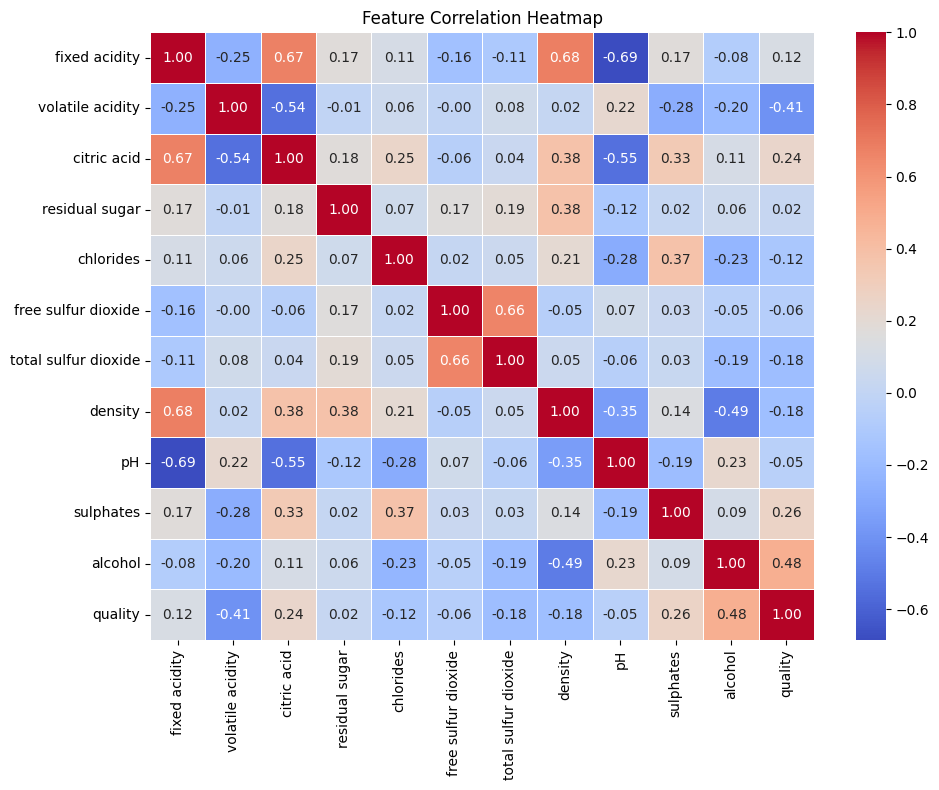

In [4]:
# Graph 2 - Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, 
            fmt='.2f', cmap='coolwarm',
            linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# Cell 5 — 3 Models Training

In [5]:
# Step 4: Model Training

# Features & Target
X = df.drop('quality', axis=1)
y = df['quality']

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

# Model 1 - Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

# Model 2 - SGD
sgd_model = SGDClassifier(random_state=42)
sgd_model.fit(X_train, y_train)
sgd_pred = sgd_model.predict(X_test)
sgd_acc = accuracy_score(y_test, sgd_pred)

# Model 3 - SVC
svc_model = SVC(random_state=42)
svc_model.fit(X_train, y_train)
svc_pred = svc_model.predict(X_test)
svc_acc = accuracy_score(y_test, svc_pred)

print("Model Accuracies:")
print(f"Random Forest: {rf_acc*100:.2f}%")
print(f"SGD: {sgd_acc*100:.2f}%")
print(f"SVC: {svc_acc*100:.2f}%")

Model Accuracies:
Random Forest: 69.43%
SGD: 59.39%
SVC: 63.76%


# Cell 6 — Model Comparison Graph

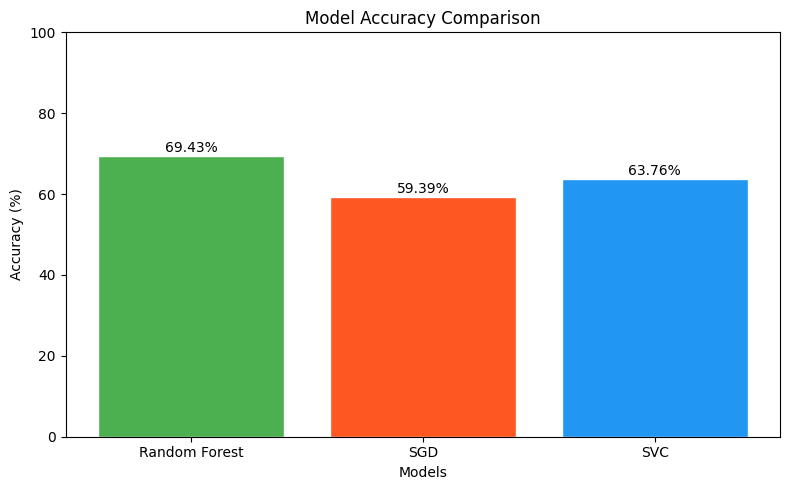

In [6]:
# Graph 3 - Model Comparison
plt.figure(figsize=(8,5))
models = ['Random Forest', 'SGD', 'SVC']
accuracies = [rf_acc*100, sgd_acc*100, svc_acc*100]
colors = ['#4CAF50', '#FF5722', '#2196F3']

plt.bar(models, accuracies, color=colors, edgecolor='white')
plt.title('Model Accuracy Comparison')
plt.xlabel('Models')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
for i, v in enumerate(accuracies):
    plt.text(i, v + 1, f'{v:.2f}%', ha='center')
plt.tight_layout()
plt.show()

# Cell 7 — Recommendations

In [8]:
# Step 5: Insights & Recommendations
print("=" * 55)
print("WINE QUALITY PREDICTION - INSIGHTS & RECOMMENDATIONS")
print("=" * 55)
print("""
MODEL PERFORMANCE:
- Random Forest: 69.43% (Best Model) 
- SVC: 63.76% 
- SGD: 59.39% 

KEY INSIGHTS:
1. ALCOHOL IS KEY FEATURE
   - Higher alcohol = Better quality wine
   - Correlation: 0.48 with quality

2. VOLATILE ACIDITY HURTS QUALITY
   - Higher volatile acidity = Lower quality
   - Correlation: -0.41 with quality

3. MOST WINES ARE AVERAGE QUALITY
   - Quality 5 & 6 dominate the dataset
   - Very few excellent wines (quality 8)

RECOMMENDATIONS:
1. Use Random Forest for best predictions
2. Focus on alcohol content for quality
3. Reduce volatile acidity for better wine
4. Collect more data for quality 3 & 8
""")
print("=" * 55)
print("Task 6 Complete! - Suraj Kumar | OIB/J2/IP2626")
print("=" * 55)

WINE QUALITY PREDICTION - INSIGHTS & RECOMMENDATIONS

MODEL PERFORMANCE:
- Random Forest: 69.43% (Best Model) 
- SVC: 63.76% 
- SGD: 59.39% 

KEY INSIGHTS:
1. ALCOHOL IS KEY FEATURE
   - Higher alcohol = Better quality wine
   - Correlation: 0.48 with quality

2. VOLATILE ACIDITY HURTS QUALITY
   - Higher volatile acidity = Lower quality
   - Correlation: -0.41 with quality

3. MOST WINES ARE AVERAGE QUALITY
   - Quality 5 & 6 dominate the dataset
   - Very few excellent wines (quality 8)

RECOMMENDATIONS:
1. Use Random Forest for best predictions
2. Focus on alcohol content for quality
3. Reduce volatile acidity for better wine
4. Collect more data for quality 3 & 8

Task 6 Complete! - Suraj Kumar | OIB/J2/IP2626
